In [289]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt, maximum_filter
from scipy.interpolate import UnivariateSpline
from scipy.spatial import cKDTree
import os
import pandas as pd


In [290]:
import numpy as np

data = np.load("/Users/administrateur/Desktop/projects_repo/dossier sans titre/this is reall/Training_database_float16/Training_database_float16/parallel_02439_curved_opposite_noisy_field.npz")

print(data.files)  # shows array names inside


['data']


In [291]:
array = data.files[0]  
array_sample = data[array]  # access the array using its name
print(array_sample.shape)
print(array_sample.dtype)

(1835, 984, 4)
float16


In [292]:
test=data[array]
rows = np.any(~np.isnan(test), axis=1)
cols = np.any(~np.isnan(test), axis=0)

rmin, rmax = np.where(rows)[0][[0, -1]]
cmin, cmax = np.where(cols)[0][[0, -1]]

cropped = test[rmin:rmax+1, cmin:cmax+1]
# Use the blue channel
img = cropped[:, :, 1]

## create centerline


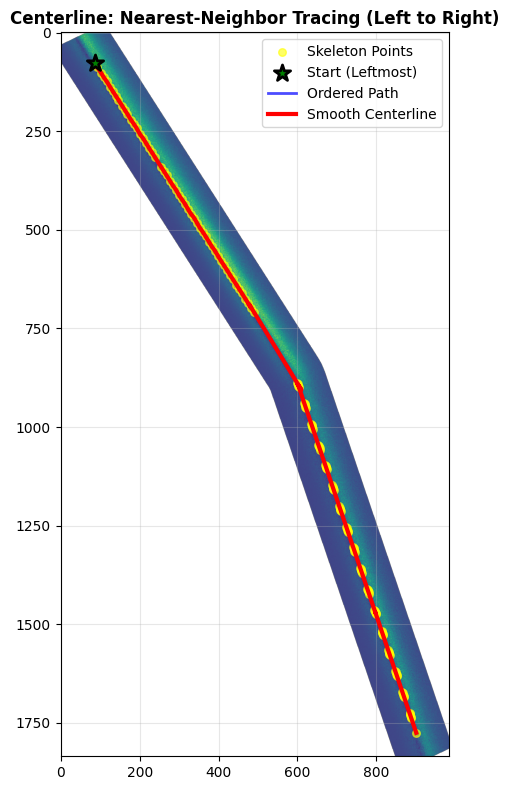

In [293]:
def create_centerline(img, max_filter_size=100, visualize=False):
   
    # Extract skeleton points
    img_mask = ~np.isnan(img)
    dist = distance_transform_edt(img_mask)
    
    # Check if image is square or nearly square (aspect ratio close to 1)
    h, w = img.shape
    aspect_ratio = max(h, w) / min(h, w)
    is_square = aspect_ratio < 1.2  # If aspect ratio is less than 1.3, treat as square
    
    if is_square and h <1000:
        print(f"Square/nearly-square image detected (aspect ratio: {aspect_ratio:.2f})")
        # For square images, use a much smaller filter to get edge points instead of center dot
        max_filter_size = max(1, min(h, w) // 8)
        if max_filter_size % 2 == 0:
            max_filter_size = 3
        print(f"Adjusted filter size for square image: {max_filter_size}")
    else:
        # Ensure filter size is odd
        
        if max_filter_size % 2 == 0:
            max_filter_size += 1
    
    skeleton_mask = (dist > 0) & img_mask & (dist == maximum_filter(dist, size=max_filter_size))
    ys_skel, xs_skel = np.where(skeleton_mask)
    
    #print(f"Skeleton points: {len(xs_skel)}")
    
    result = {
        'xs_smooth': np.array([]),
        'ys_smooth': np.array([]),
        'xs_ordered': np.array([]),
        'ys_ordered': np.array([]),
        'xs_skel': xs_skel,
        'ys_skel': ys_skel,
        'success': False
    }
    
    if len(xs_skel) <= 2:
        print("ERROR: Not enough skeleton points")
        return result
    
    # Order skeleton points using nearest-neighbor with KDTree
    points = np.column_stack([xs_skel, ys_skel])
    tree = cKDTree(points)
    
    # Start from leftmost point
    start_idx = np.argmin(xs_skel)
    ordered = [points[start_idx]]
    visited = {start_idx}
    
    # Greedily connect nearest unvisited neighbors
    while len(visited) < len(points):
        current = ordered[-1]
        _, unvisited_idx = tree.query(current, k=len(points))
        for idx in unvisited_idx:
            if idx not in visited:
                ordered.append(points[idx])
                visited.add(idx)
                break
    
    ordered = np.array(ordered)
    xs_ordered = ordered[:, 0]
    ys_ordered = ordered[:, 1]
    
    # Smooth the centerline
    try:
        t = np.linspace(0, 1, len(ordered))
        spl_x = UnivariateSpline(t, xs_ordered, s=10, k=min(3, len(ordered)-1))
        spl_y = UnivariateSpline(t, ys_ordered, s=10, k=min(3, len(ordered)-1))
        t_smooth = np.linspace(0, 1, 300)
        xs_smooth = spl_x(t_smooth)
        ys_smooth = spl_y(t_smooth)
    except:
        xs_smooth = xs_ordered
        ys_smooth = ys_ordered
    
    # Update result dictionary
    result['xs_smooth'] = xs_smooth
    result['ys_smooth'] = ys_smooth
    result['xs_ordered'] = xs_ordered
    result['ys_ordered'] = ys_ordered
    result['success'] = True
    
    # Visualization if requested
    if visualize:
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.imshow(img, cmap='viridis')
        ax.scatter(xs_skel, ys_skel, c='yellow', s=30, alpha=0.6, label='Skeleton Points', zorder=3)
        ax.scatter([xs_skel[start_idx]], [ys_skel[start_idx]], c='green', s=150, marker='*', 
                   label='Start (Leftmost)', zorder=5, edgecolors='black', linewidths=2)
        ax.plot(xs_ordered, ys_ordered, 'b-', linewidth=2, label='Ordered Path', alpha=0.7, zorder=2)
        ax.plot(xs_smooth, ys_smooth, 'r-', linewidth=3, label='Smooth Centerline', zorder=4)
        ax.set_title('Centerline: Nearest-Neighbor Tracing (Left to Right)', fontweight='bold', fontsize=12)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    #print(f"✓ Centerline traced starting from leftmost point (x={xs_skel[start_idx]:.0f})")
    #print(f"✓ Smooth centerline: {len(xs_smooth)} points")
    
    return result

# Calculate max_filter_size as 1/5 of the height of the scan
max_filter_size = max(1, int(img.shape[0] / 6))
# Example usage: create centerline with visualization
centerline = create_centerline(img, max_filter_size=max_filter_size, visualize=True)
# Access the smooth centerline
xs_smooth = centerline['xs_smooth']
ys_smooth = centerline['ys_smooth']

## calculate widths

In [294]:
def compute_width_along_centerline(img: np.ndarray, xs_center: np.ndarray, ys_center: np.ndarray, mask: np.ndarray | None = None):

   


    img = np.asarray(img)

    xs_center = np.asarray(xs_center)

    ys_center = np.asarray(ys_center)




    if mask is None:

        mask = ~np.isnan(img)

    else:

        mask = np.asarray(mask, dtype=bool)


#basically enforces that they should have the same shape
    
    assert img.shape == mask.shape, "img and mask must have same shape"

    assert xs_center.shape == ys_center.shape, "xs_center and ys_center must have same shape"



    h, w = img.shape

    n = xs_center.size

    widths = np.zeros(n, dtype=float)



    # Helper to get local tangent

    dxs = np.gradient(xs_center.astype(float))

    dys = np.gradient(ys_center.astype(float))



    for i in range(n):

        x0 = float(xs_center[i])

        y0 = float(ys_center[i])



        # Local tangent (dx, dy); normal is perpendicular to this

        dx = dxs[i]

        dy = dys[i]

        # If tangent is not valid, skip

        if dx == 0 and dy == 0:

            widths[i] = np.nan

            continue



        # Normal vector (nx, ny) perpendicular to (dx, dy)

        nx = -dy

        ny = dx

        norm = np.hypot(nx, ny)

        if norm == 0:

            widths[i] = np.nan

            continue

        nx /= norm

        ny /= norm



        # March along normal in + and - directions until leaving mask

        def walk(sign: int) -> float:

            t = 0.0

            step = 0.5  

            while True:

                t += step

                x = int(round(x0 + sign * t * nx))

                y = int(round(y0 + sign * t * ny))

                if x < 0 or x >= w or y < 0 or y >= h:

                    return (t - step)

                if not mask[y, x]:

                    return (t - step)



        t_plus = walk(+1)

        t_minus = walk(-1)



        # get total width as sum of both sides, sometimes better accuracy than just 2*t_plus or 2*t_minus 

        widths[i] = t_plus + t_minus



    return widths


def analyze_widths(img: np.ndarray, xs_center: np.ndarray, ys_center: np.ndarray, 
                   pixel_to_meter: float = 0.2, rounding_precision: int = 1):
    
    result = {
        'widths': np.array([]),
        'valid_widths': np.array([]),
        'rounded': np.array([]),
        'most_recurring_width_px': None,
        'most_recurring_width_m': None,
        'success': False
    }
    
    # Compute widths
    mask = ~np.isnan(img)
    widths = compute_width_along_centerline(img, xs_center, ys_center, mask=mask)
    result['widths'] = widths
    
    # Remove NaNs and round
    valid_widths = widths[~np.isnan(widths)]
    result['valid_widths'] = valid_widths
    
    rounded = np.round(valid_widths, rounding_precision)
    result['rounded'] = rounded
    
    if rounded.size > 0:
        # Find the most frequent value
        values, counts = np.unique(rounded, return_counts=True)
        most_recurring_width_px = values[np.argmax(counts)]
        most_recurring_width_m = most_recurring_width_px * pixel_to_meter
        
        result['most_recurring_width_px'] = most_recurring_width_px
        result['most_recurring_width_m'] = most_recurring_width_m
        result['success'] = True
        
        #print(f"Most recurring width (pixels): {most_recurring_width_px}")
        print(f"Most recurring width (meters): {most_recurring_width_m:.2f}")
    else:
        print("No valid widths computed")
    
    return result


# Call the function
width_analysis = analyze_widths(img, xs_smooth, ys_smooth, pixel_to_meter=0.2, rounding_precision=1)


Most recurring width (meters): 28.90


# straighten the curved scan



CENTERLINE ANALYSIS
Number of points: 300
Total centerline length: 2097.38 pixels
Average segment length: 7.0147 pixels
Min segment length: 0.0216 pixels
Max segment length: 109.4073 pixels
Std dev of segments: 9.6406 pixels


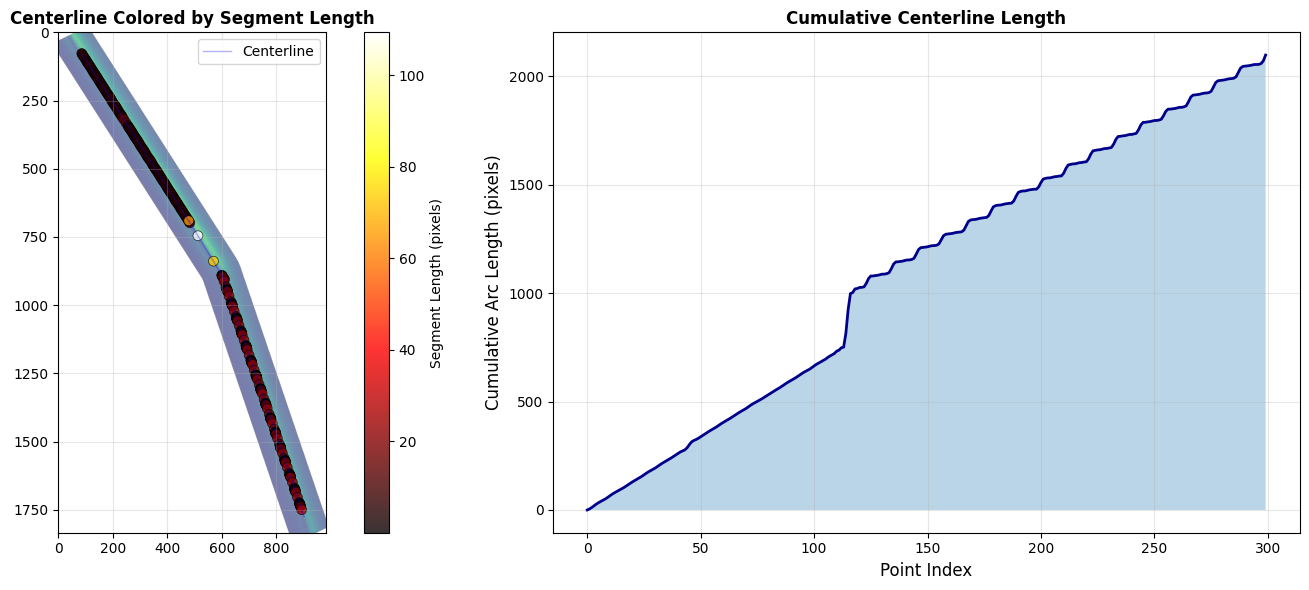

In [295]:

# Calculate actual centerline length
def calculate_centerline_length(xs, ys):
    """
    Calculate the actual arc length of the centerline.
    
    Args:
        xs: x coordinates of centerline
        ys: y coordinates of centerline
    
    Returns:
        total_length: sum of distances between consecutive points
        segment_lengths: distances between each pair of consecutive points
        num_points: number of points in centerline
    """
    # Calculate distances between consecutive points
    dx = np.diff(xs)
    dy = np.diff(ys)
    segment_lengths = np.sqrt(dx**2 + dy**2)
    
    # Total length is sum of all segments
    total_length = np.sum(segment_lengths)
    num_points = len(xs)
    
    return total_length, segment_lengths, num_points


# Calculate centerline length
centerline_length, segment_lengths, num_points = calculate_centerline_length(xs_smooth, ys_smooth)

print(f"\n{'='*60}")
print(f"CENTERLINE ANALYSIS")
print(f"{'='*60}")
print(f"Number of points: {num_points}")
print(f"Total centerline length: {centerline_length:.2f} pixels")
print(f"Average segment length: {np.mean(segment_lengths):.4f} pixels")
print(f"Min segment length: {np.min(segment_lengths):.4f} pixels")
print(f"Max segment length: {np.max(segment_lengths):.4f} pixels")
print(f"Std dev of segments: {np.std(segment_lengths):.4f} pixels")

# Visualize the centerline with segment information
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Original image with centerline colored by segment length
axes[0].imshow(img, cmap='viridis', alpha=0.7)
scatter = axes[0].scatter(xs_smooth[:-1], ys_smooth[:-1], c=segment_lengths, 
                          cmap='hot', s=50, alpha=0.8, edgecolors='black', linewidth=0.5)
axes[0].plot(xs_smooth, ys_smooth, 'b-', linewidth=1, alpha=0.3, label='Centerline')
axes[0].set_title('Centerline Colored by Segment Length', fontweight='bold', fontsize=12)
axes[0].legend()
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Segment Length (pixels)')
axes[0].grid(True, alpha=0.3)

# Plot 2: Cumulative arc length
cumulative_length = np.concatenate([[0], np.cumsum(segment_lengths)])
axes[1].plot(cumulative_length, linewidth=2, color='darkblue')
axes[1].fill_between(range(len(cumulative_length)), cumulative_length, alpha=0.3)
axes[1].set_xlabel('Point Index', fontsize=12)
axes[1].set_ylabel('Cumulative Arc Length (pixels)', fontsize=12)
axes[1].set_title('Cumulative Centerline Length', fontweight='bold', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Straightening with width: 260 pixels on each side
Actual straightened height based on arc length: 2098 pixels


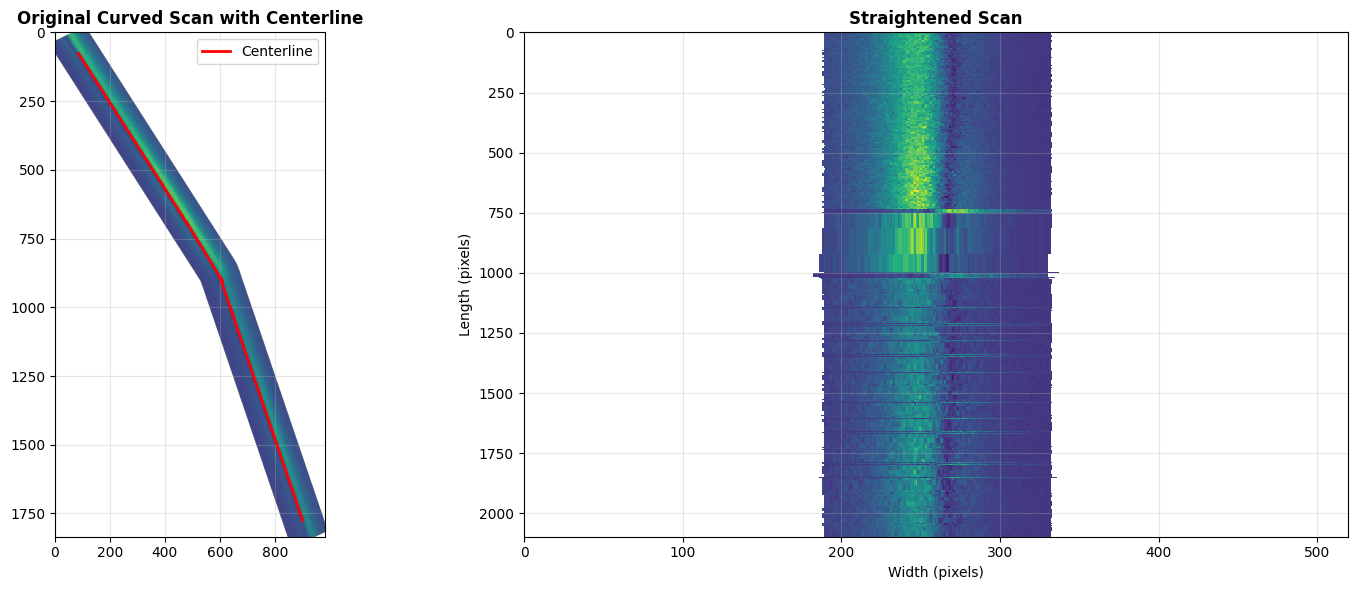

Straightened scan shape: (2098, 520)
Cleaned straightened scan shape: (0, 520)


In [296]:
def straighten_scan(img, xs_centerline, ys_centerline, width=None, visualize=False):
    """
    Straighten a curved scan using the centerline.
    Uses actual arc length for accurate height calculation.
    
    Args:
        img: 2D image array
        xs_centerline: x coordinates of centerline
        ys_centerline: y coordinates of centerline
        width: width to extract on each side of centerline (if None, auto-detects)
        visualize: whether to show before/after visualization
    
    Returns:
        straightened_img: straightened rectangular image (NaN where out of bounds)
    """
    from scipy.interpolate import interp1d
    
    h, w = img.shape
    
    # Compute tangent vectors along the centerline (derivatives)
    dx = np.gradient(xs_centerline)
    dy = np.gradient(ys_centerline)
    
    # Normalize tangent vectors
    magnitude = np.sqrt(dx**2 + dy**2)
    dx_norm = dx / (magnitude + 1e-10)
    dy_norm = dy / (magnitude + 1e-10)
    
    # Perpendicular vectors (rotate 90 degrees)
    px = -dy_norm
    py = dx_norm
    
    # Determine extraction width if not provided
    if width is None:
        # Find valid width at each point along centerline
        widths_per_point = []
        for i in range(len(xs_centerline)):
            x, y = xs_centerline[i], ys_centerline[i]
            px_i, py_i = px[i], py[i]
            
            # Find max valid distance in positive direction
            max_dist_pos = 0
            for d in range(1, max(h, w)):
                x_test = x + d * px_i
                y_test = y + d * py_i
                if 0 <= x_test < w and 0 <= y_test < h:
                    max_dist_pos = d
                else:
                    break
            
            # Find max valid distance in negative direction
            max_dist_neg = 0
            for d in range(1, max(h, w)):
                x_test = x - d * px_i
                y_test = y - d * py_i
                if 0 <= x_test < w and 0 <= y_test < h:
                    max_dist_neg = d
                else:
                    break
            
            widths_per_point.append((max_dist_pos, max_dist_neg))
        
        # Use the 25th percentile to avoid outliers (which create weird lines)
        all_widths = np.array(widths_per_point).flatten()
        width = int(np.percentile(all_widths, 25)) if len(all_widths) > 0 else 50
    
    print(f"Straightening with width: {width} pixels on each side")
    
    # Calculate actual centerline arc length instead of using point count
    dx_arc = np.diff(xs_centerline)
    dy_arc = np.diff(ys_centerline)
    segment_lengths = np.sqrt(dx_arc**2 + dy_arc**2)
    actual_length = np.sum(segment_lengths)
    straightened_height = int(np.ceil(actual_length))
    
    straightened_width = 2 * width
    straightened_img = np.full((straightened_height, straightened_width), np.nan)
    
    # Create cumulative arc length for proper row indexing
    cumulative_length = np.concatenate([[0], np.cumsum(segment_lengths)])
    
    # Extract perpendicular profiles based on arc length
    for i in range(len(xs_centerline) - 1):
        x_center = xs_centerline[i]
        y_center = ys_centerline[i]
        px_i = px[i]
        py_i = py[i]
        
        # Calculate number of rows for this segment based on arc length
        segment_start_row = int(np.round(cumulative_length[i]))
        segment_end_row = int(np.round(cumulative_length[i + 1]))
        num_rows_in_segment = segment_end_row - segment_start_row
        
        # Extract profiles for this segment
        for row_offset in range(max(1, num_rows_in_segment)):
            out_row = segment_start_row + row_offset
            if out_row >= straightened_height:
                break
            
            # Extract profile perpendicular to centerline
            profile = []
            for d in range(-width, width):
                x_sample = x_center + d * px_i
                y_sample = y_center + d * py_i
                
                # Check if sample is within image bounds with margin
                if 0 <= x_sample < w and 0 <= y_sample < h:
                    # Bilinear interpolation
                    x_int = int(np.floor(x_sample))
                    y_int = int(np.floor(y_sample))
                    x_frac = x_sample - x_int
                    y_frac = y_sample - y_int
                    
                    # Ensure indices don't go out of bounds
                    if x_int >= w-1:
                        x_int = w - 2
                    if y_int >= h-1:
                        y_int = h - 2
                    
                    # Check if value is not NaN
                    if not (np.isnan(img[y_int, x_int]) or np.isnan(img[y_int, x_int+1]) or 
                            np.isnan(img[y_int+1, x_int]) or np.isnan(img[y_int+1, x_int+1])):
                        # Bilinear interpolation
                        val = (1-x_frac)*(1-y_frac) * img[y_int, x_int] + \
                              x_frac*(1-y_frac) * img[y_int, x_int+1] + \
                              (1-x_frac)*y_frac * img[y_int+1, x_int] + \
                              x_frac*y_frac * img[y_int+1, x_int+1]
                        profile.append(val)
                    else:
                        profile.append(np.nan)
                else:
                    profile.append(np.nan)
            
            if out_row < straightened_height:
                straightened_img[out_row, :] = profile
    
    print(f"Actual straightened height based on arc length: {straightened_height} pixels")
    
    if visualize:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Original with centerline
        axes[0].imshow(img, cmap='viridis')
        axes[0].plot(xs_centerline, ys_centerline, 'r-', linewidth=2, label='Centerline')
        axes[0].set_title('Original Curved Scan with Centerline', fontweight='bold', fontsize=12)
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Straightened - mask NaN values to avoid weird lines
        straightened_masked = np.ma.masked_invalid(straightened_img)
        axes[1].imshow(straightened_masked, cmap='viridis', aspect='auto', interpolation='nearest')
        axes[1].set_title('Straightened Scan', fontweight='bold', fontsize=12)
        axes[1].set_xlabel('Width (pixels)')
        axes[1].set_ylabel('Length (pixels)')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    return straightened_img

# Straighten the scan
straightened = straighten_scan(img, xs_smooth, ys_smooth, visualize=True)

# Remove rows that are mostly NaN (which cause the weird lines)
valid_rows = np.sum(~np.isnan(straightened), axis=1) > straightened.shape[1] * 0.5
straightened_clean = straightened[valid_rows, :]

print(f"Straightened scan shape: {straightened.shape}")
print(f"Cleaned straightened scan shape: {straightened_clean.shape}")

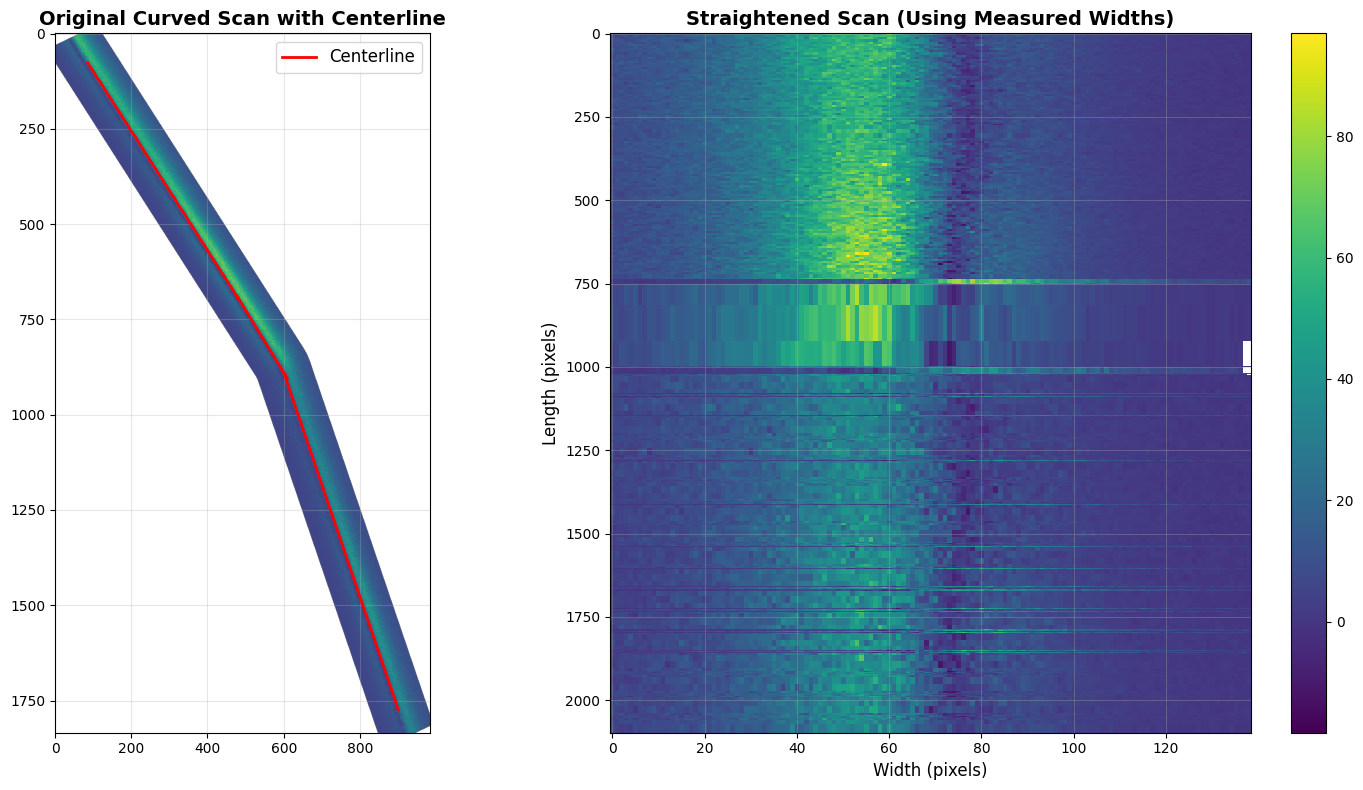


✓ Scan straightened successfully using measured widths!
  Original shape: (1835, 984)
  Straightened shape: (2098, 520)
  Most recurring width (pixels): 144
  Final output shape (using measured width): (2098, 139)


In [297]:

# Use the calculated widths instead of random cropping
widths = width_analysis['widths']
valid_widths = width_analysis['valid_widths']
most_recurring_width_px = width_analysis['most_recurring_width_px']

# Get the actual width to extract
width_px = int(most_recurring_width_px)

# The straightened image has width = 2 * width (from the straighten_scan function)
# The center of the straightened image is at straightened.shape[1] // 2
# We want to crop symmetrically around this center

straightened_center = straightened.shape[1] // 2
half_width = width_px // 2
# Calculate start and end columns, centered on the straightened image
center_col_start = straightened_center - half_width +5
center_col_end = center_col_start + width_px-5

# Clamp to valid range
center_col_start = max(0, center_col_start)
center_col_end = min(straightened.shape[1], center_col_end)

straightened_cropped = straightened[:, center_col_start:center_col_end]

# Better visualization: show only the clean central region
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Original with centerline
axes[0].imshow(img, cmap='viridis')
axes[0].plot(xs_smooth, ys_smooth, 'r-', linewidth=2, label='Centerline')
axes[0].set_title('Original Curved Scan with Centerline', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Straightened - using calculated widths
straightened_masked = np.ma.masked_invalid(straightened_cropped)
im = axes[1].imshow(straightened_masked, cmap='viridis', aspect='auto', interpolation='none')
axes[1].set_title('Straightened Scan (Using Measured Widths)', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Width (pixels)', fontsize=12)
axes[1].set_ylabel('Length (pixels)', fontsize=12)
axes[1].grid(True, alpha=0.3)
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

print(f"\n✓ Scan straightened successfully using measured widths!")
print(f"  Original shape: {img.shape}")
print(f"  Straightened shape: {straightened.shape}")
print(f"  Most recurring width (pixels): {width_px}")
print(f"  Final output shape (using measured width): {straightened_cropped.shape}")


## crop the scan into standard size for cnn training




✓ Image cropped into square patches:
  Square size: 128x128 pixels
  Overlap: 0 pixels
  Total patches extracted: 16
  Original image shape: 2098 x 139
  Patches per row: 1


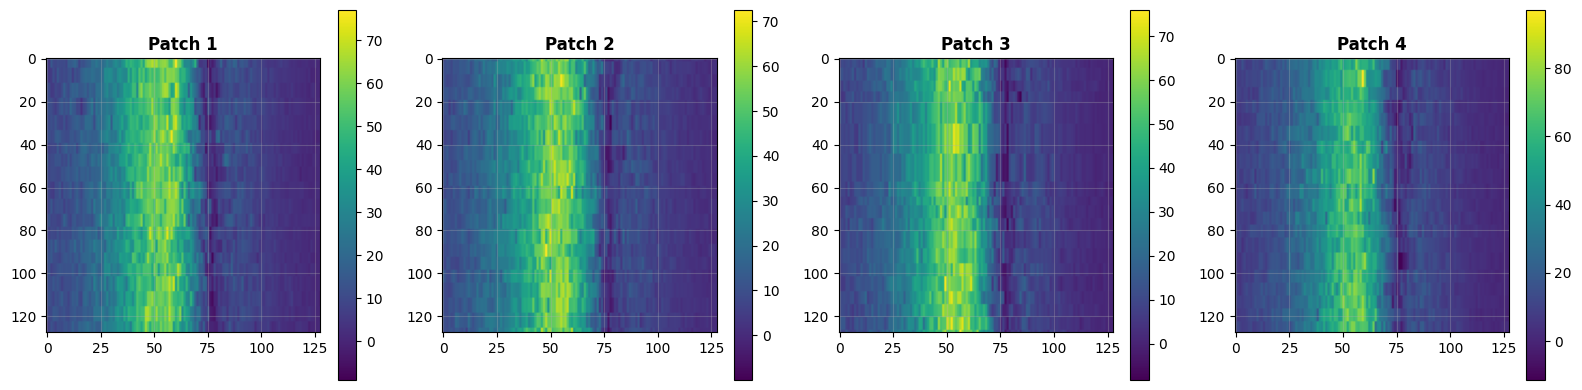


Patch statistics:
  Valid pixels: 16384/16384 (100.0%)
  Valid pixels: 16384/16384 (100.0%)
  Valid pixels: 16384/16384 (100.0%)
  Valid pixels: 16384/16384 (100.0%)
  Valid pixels: 16384/16384 (100.0%)
  Valid pixels: 16384/16384 (100.0%)
  Valid pixels: 16384/16384 (100.0%)
  Valid pixels: 16384/16384 (100.0%)
  Valid pixels: 16384/16384 (100.0%)
  Valid pixels: 16384/16384 (100.0%)
  Valid pixels: 16384/16384 (100.0%)
  Valid pixels: 16384/16384 (100.0%)
  Valid pixels: 16384/16384 (100.0%)
  Valid pixels: 16384/16384 (100.0%)
  Valid pixels: 16384/16384 (100.0%)
  Valid pixels: 16384/16384 (100.0%)


In [298]:
def crop_into_squares(img, square_size=256, overlap=0, visualize=False):
    """
    Crop a 2D image into equal-sized square patches for CNN input.
    
    Args:
        img: 2D image array
        square_size: size of the square patches (default 256 for common CNN input)
        overlap: number of pixels to overlap between patches (default 0)
        visualize: whether to show sample patches
    
    Returns:
        patches: list of square patches as numpy arrays
        patch_info: dict with metadata about patches
    """
    h, w = img.shape
    stride = square_size - overlap
    
    patches = []
    patch_coords = []
    
    # Extract patches with sliding window
    for y in range(0, h - square_size + 1, stride):
        for x in range(0, w - square_size + 1, stride):
            patch = img[y:y+square_size, x:x+square_size]
            
            # Skip patches that are mostly NaN
            valid_pixels = np.sum(~np.isnan(patch))
            total_pixels = square_size * square_size
            validity_ratio = valid_pixels / total_pixels
            
            if validity_ratio > 0.5:  # Keep patches with > 50% valid data
                patches.append(patch)
                patch_coords.append((y, x))
    
    # Collect statistics
    patch_info = {
        'total_patches': len(patches),
        'square_size': square_size,
        'overlap': overlap,
        'stride': stride,
        'original_shape': img.shape,
        'patch_coords': patch_coords,
        'validity_threshold': 0.5
    }
    
    print(f"\n✓ Image cropped into square patches:")
    print(f"  Square size: {square_size}x{square_size} pixels")
    print(f"  Overlap: {overlap} pixels")
    print(f"  Total patches extracted: {len(patches)}")
    print(f"  Original image shape: {h} x {w}")
    print(f"  Patches per row: {len([p for p in patch_coords if p[0] == 0])}")
    
    if visualize and len(patches) > 0:
        # Show first 4 patches as examples
        n_show = min(4, len(patches))
        fig, axes = plt.subplots(1, n_show, figsize=(4*n_show, 4))
        if n_show == 1:
            axes = [axes]
        
        for idx in range(n_show):
            im = axes[idx].imshow(patches[idx], cmap='viridis')
            axes[idx].set_title(f'Patch {idx+1}', fontweight='bold')
            axes[idx].grid(True, alpha=0.3)
            plt.colorbar(im, ax=axes[idx])
        
        plt.tight_layout()
        plt.show()
    
    return patches, patch_info


# Crop the straightened image into equal-sized squares
# Standard CNN input sizes: 224, 256, 512
square_size = 128
overlap = 0  # Set to > 0 if you want overlapping patches

patches, patch_info = crop_into_squares(straightened_cropped, square_size=square_size, overlap=overlap, visualize=True)

print(f"\nPatch statistics:")
for patch in patches:
    valid = np.sum(~np.isnan(patch))
    total = patch.size
    print(f"  Valid pixels: {valid}/{total} ({100*valid/total:.1f}%)")
